In [1]:
import pickle
import numpy as np

with open('/scratch/e1498138/sobol/noise/tpmax/ckpt_1e5/final.pkl', 'rb') as f:
    phys_pts, logden = pickle.load(f)

i = np.argmax(logden)
logm1, logm2, a, p0, e0 = phys_pts[i]

print(f"max log-density: {logden[i]:.6f}")
print(f"log10 m1 = {logm1:.6f}  ->  m1 = {10**logm1:.6e}")
print(f"log10 m2 = {logm2:.6f}  ->  m2 = {10**logm2:.6e}")
print(f"a  = {a:.6f}")
print(f"p0 = {p0:.6f}")
print(f"e0 = {e0:.6f}")

max log-density: 5.705453
log10 m1 = 6.059522  ->  m1 = 1.146890e+06
log10 m2 = 0.825574  ->  m2 = 6.692285e+00
a  = 0.416593
p0 = 8.906924
e0 = 0.434336


In [2]:
import pickle
import numpy as np

# ---------------------------------------------------------------------
# 1. Runtime scaling (measured from actual runs, both ~4.4-4.5 samples/s
#    since the FEW likelihood eval dominates, not the sampling design)
# ---------------------------------------------------------------------
rate_sobol = 100000 / 22633   # samples/s, from sobol_noise_tpmax.out
rate_lhs   = 100000 / 22143   # samples/s, from lhs_noise_1e5_new.out

n_list = [1e5, 5e5, 1e6, 5e6, 1e7]

print(f"{'N':>12} | {'Sobol (hr)':>12} | {'LHS (hr)':>12}")
for n in n_list:
    t_sobol = n / rate_sobol / 3600
    t_lhs   = n / rate_lhs / 3600
    print(f"{n:12.0e} | {t_sobol:12.2f} | {t_lhs:12.2f}")

# ---------------------------------------------------------------------
# 2. How many samples needed to land inside the Fisher-predicted peak
#    (cov_matrix_noise_1yr.pkl), given space-filling spacing ~ N^(-1/d)
# ---------------------------------------------------------------------
with open('/nfs/home/svu/e1498138/emri_search/work/cov_matrix_noise_1yr.pkl', 'rb') as f:
    cov = pickle.load(f)

ndim = cov.shape[0]  # 5: [log10 m1, log10 m2, a, p0, e0]

# 1-sigma semi-axis lengths of the Fisher ellipsoid (peak width per dim)
eigvals = np.linalg.eigvalsh(cov)
sigma_axes = np.sqrt(eigvals)
peak_scale = np.prod(sigma_axes) ** (1.0 / ndim)  # geometric-mean peak width

# prior box volume (same param_ranges as run_sobol_noise.py / run_lhs_noise.py)
param_ranges = [(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]
box_widths = np.array([hi - lo for lo, hi in param_ranges])
box_scale = np.prod(box_widths) ** (1.0 / ndim)  # geometric-mean box width

# measured empirical fact from the docstring: at N=1e5, spacing is
# ~50x wider than the peak. Calibrate the N^(-1/d) law to that anchor.
N_ref = 1e5
spacing_ratio_ref = 50.0  # spacing / peak_scale at N_ref

# spacing(N) = spacing_ratio_ref * peak_scale * (N/N_ref)^(-1/ndim)
def spacing_ratio(N):
    return spacing_ratio_ref * (N / N_ref) ** (-1.0 / ndim)

# N needed to bring spacing down to 1x the peak width (i.e. "land" in it)
N_needed = N_ref * spacing_ratio_ref ** ndim

print(f"\nPeak geometric-mean 1-sigma width: {peak_scale:.4g}")
print(f"Prior box geometric-mean width:    {box_scale:.4g}")
print(f"Spacing/peak ratio at N=1e5:       {spacing_ratio(1e5):.1f}x")
print(f"Spacing/peak ratio at N=5e5:       {spacing_ratio(5e5):.1f}x")
print(f"Spacing/peak ratio at N=1e6:       {spacing_ratio(1e6):.1f}x")
print(f"N required for spacing ~ peak width: {N_needed:.3e}")
print(f"  -> runtime at Sobol rate: {N_needed/rate_sobol/3600/24/365:.2e} years")
print(f"  -> runtime at LHS rate:   {N_needed/rate_lhs/3600/24/365:.2e} years")

           N |   Sobol (hr) |     LHS (hr)
       1e+05 |         6.29 |         6.15
       5e+05 |        31.43 |        30.75
       1e+06 |        62.87 |        61.51
       5e+06 |       314.35 |       307.54
       1e+07 |       628.69 |       615.08

Peak geometric-mean 1-sigma width: 9.02e-06
Prior box geometric-mean width:    0.7569
Spacing/peak ratio at N=1e5:       50.0x
Spacing/peak ratio at N=5e5:       36.2x
Spacing/peak ratio at N=1e6:       31.5x
N required for spacing ~ peak width: 3.125e+13
  -> runtime at Sobol rate: 2.24e+05 years
  -> runtime at LHS rate:   2.19e+05 years


In [ ]:
param_ranges = [
    (5.6,  6.4),
    (0.8,  1.3),
    (0.3,  0.99),
    (8.0,  11.0),
    (0.2,  0.5),
]
prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])


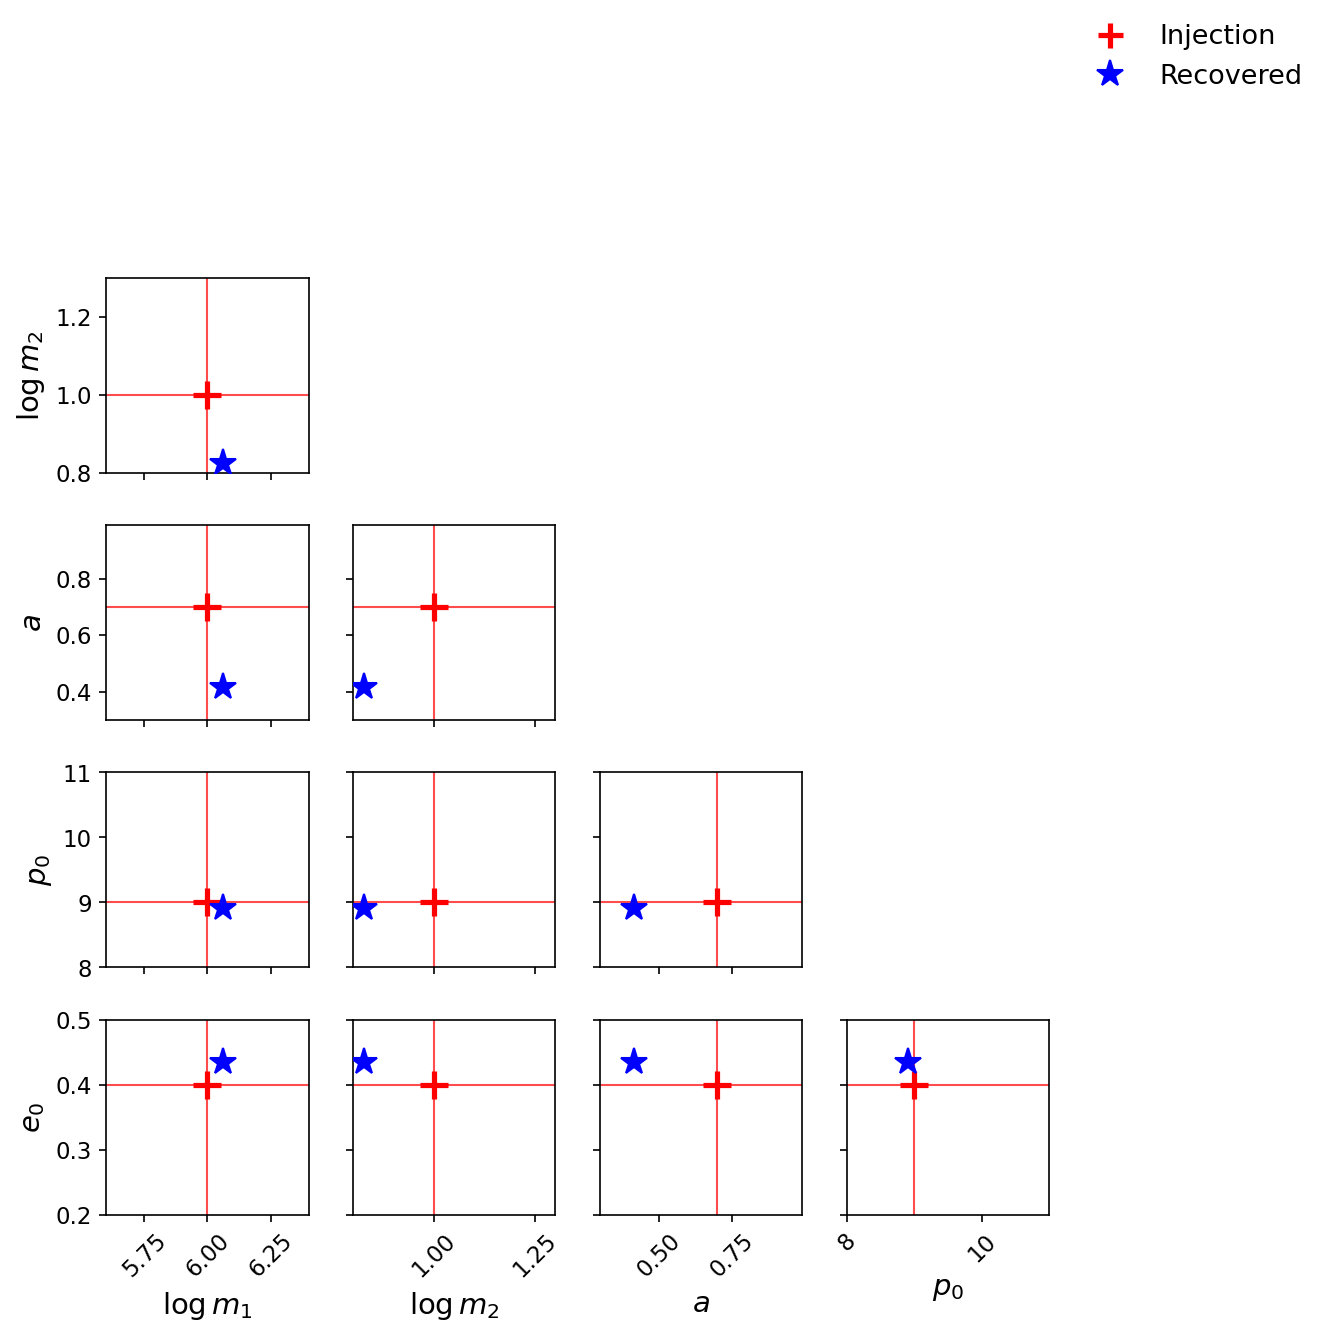

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

# injected (true) params: m1=1e6, m2=10, a=0.7, p0=9, e0=0.4
param_true = np.array([np.log10(1e6), np.log10(10), 0.7, 9.0, 0.4])

# Sobol max-log-density point (final.pkl, ckpt_1e5)
maxld_pt1 = np.array([6.059522, 0.825574, 0.416593, 8.906924, 0.434336])

param_ranges = [(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

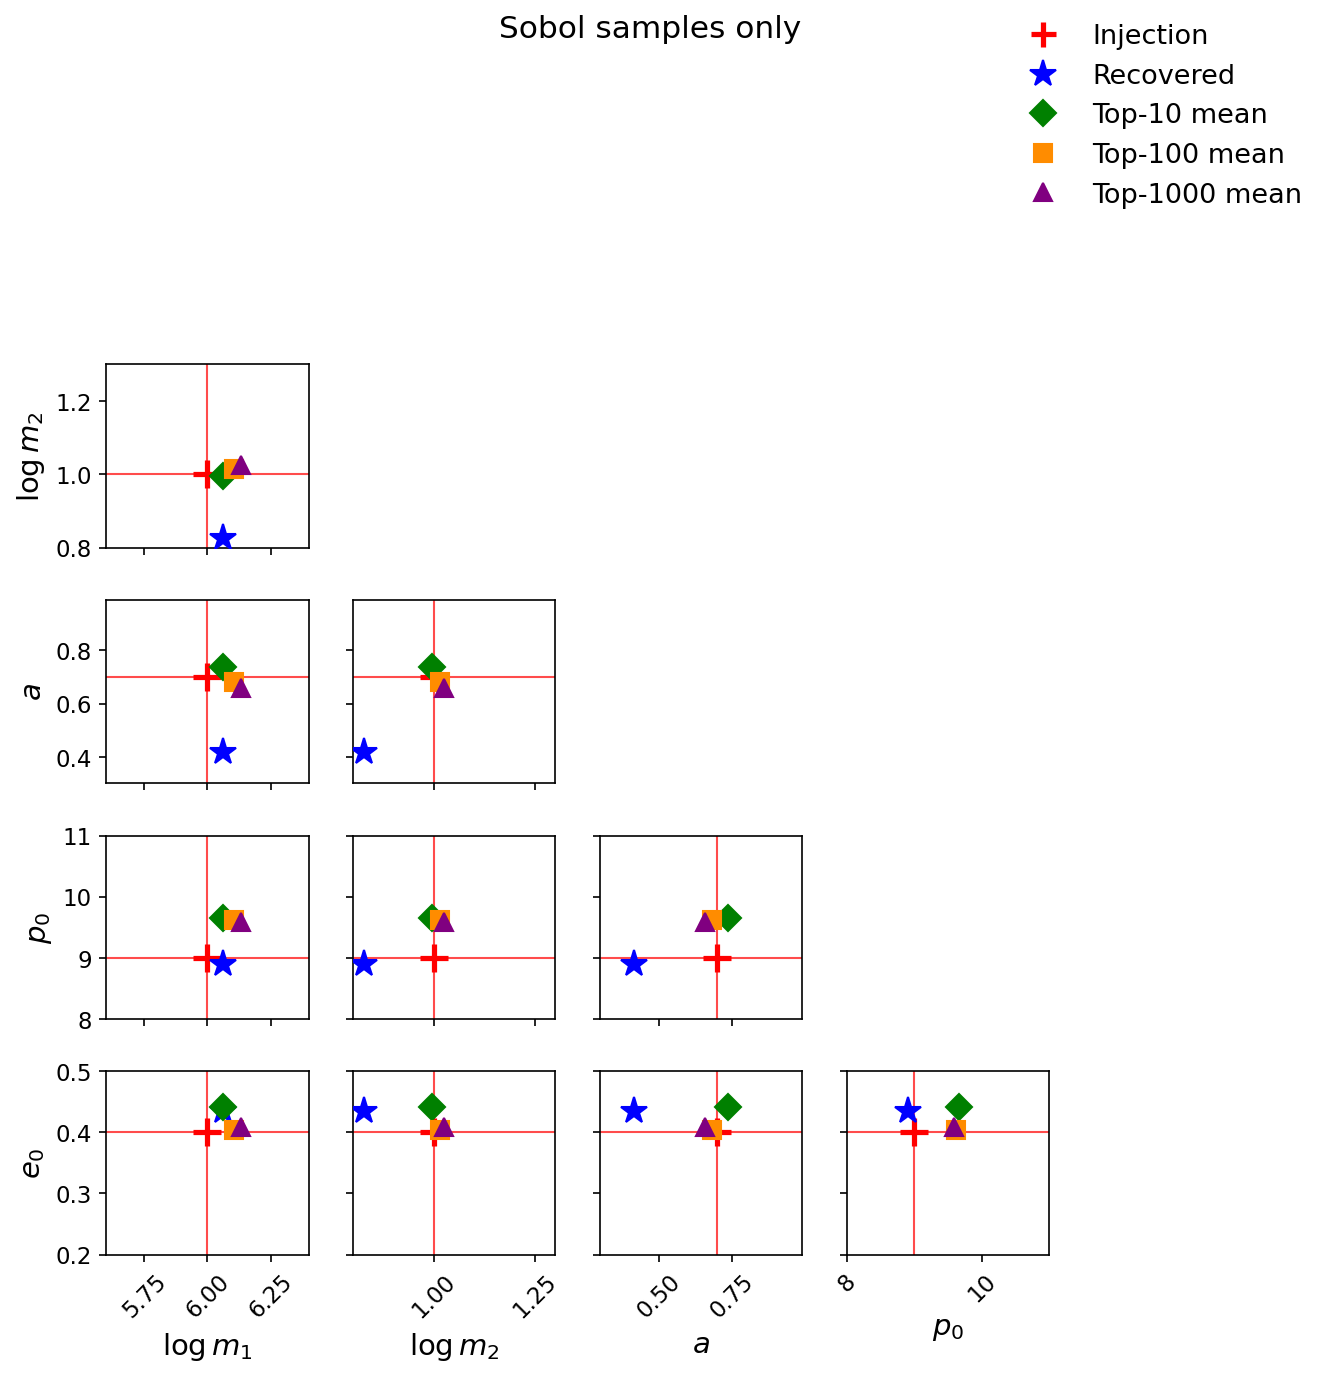

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

# injected (true) params: m1=1e6, m2=10, a=0.7, p0=9, e0=0.4
param_true = np.array([np.log10(1e6), np.log10(10), 0.7, 9.0, 0.4])

# Sobol max-log-density point (final.pkl, ckpt_1e5)
maxld_pt1 = np.array([6.059522, 0.825574, 0.416593, 8.906924, 0.434336])

param_ranges = [(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

# mean of the top-10 / top-100 / top-1000 Sobol samples by log-density
sorted_idx = np.argsort(logden)
topN_means = {}
topN_colors = {10: 'green', 100: 'darkorange', 1000: 'purple'}
topN_markers = {10: 'D', 100: 's', 1000: '^'}
for N in [10, 100, 1000]:
    idx = sorted_idx[-N:]
    topN_means[N] = phys_pts[idx].mean(axis=0)

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        for N, pt in topN_means.items():
            ax.plot(pt[j], pt[i], topN_markers[N], color=topN_colors[N],
                    ms=9, zorder=4)

        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
] + [
    Line2D([0], [0], color=topN_colors[N], marker=topN_markers[N], ls='', ms=9,
           label=f'Top-{N} mean')
    for N in [10, 100, 1000]
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.suptitle('Sobol samples only', fontsize=15, y=1.02)
fig.tight_layout()

In [6]:
topN_means

{10: array([6.0604007 , 0.99523026, 0.73732046, 9.65927046, 0.44170136]),
 100: array([6.10692362, 1.01395474, 0.68054197, 9.6139338 , 0.40316436]),
 1000: array([6.13323422, 1.02555055, 0.65741891, 9.58977176, 0.40915506])}

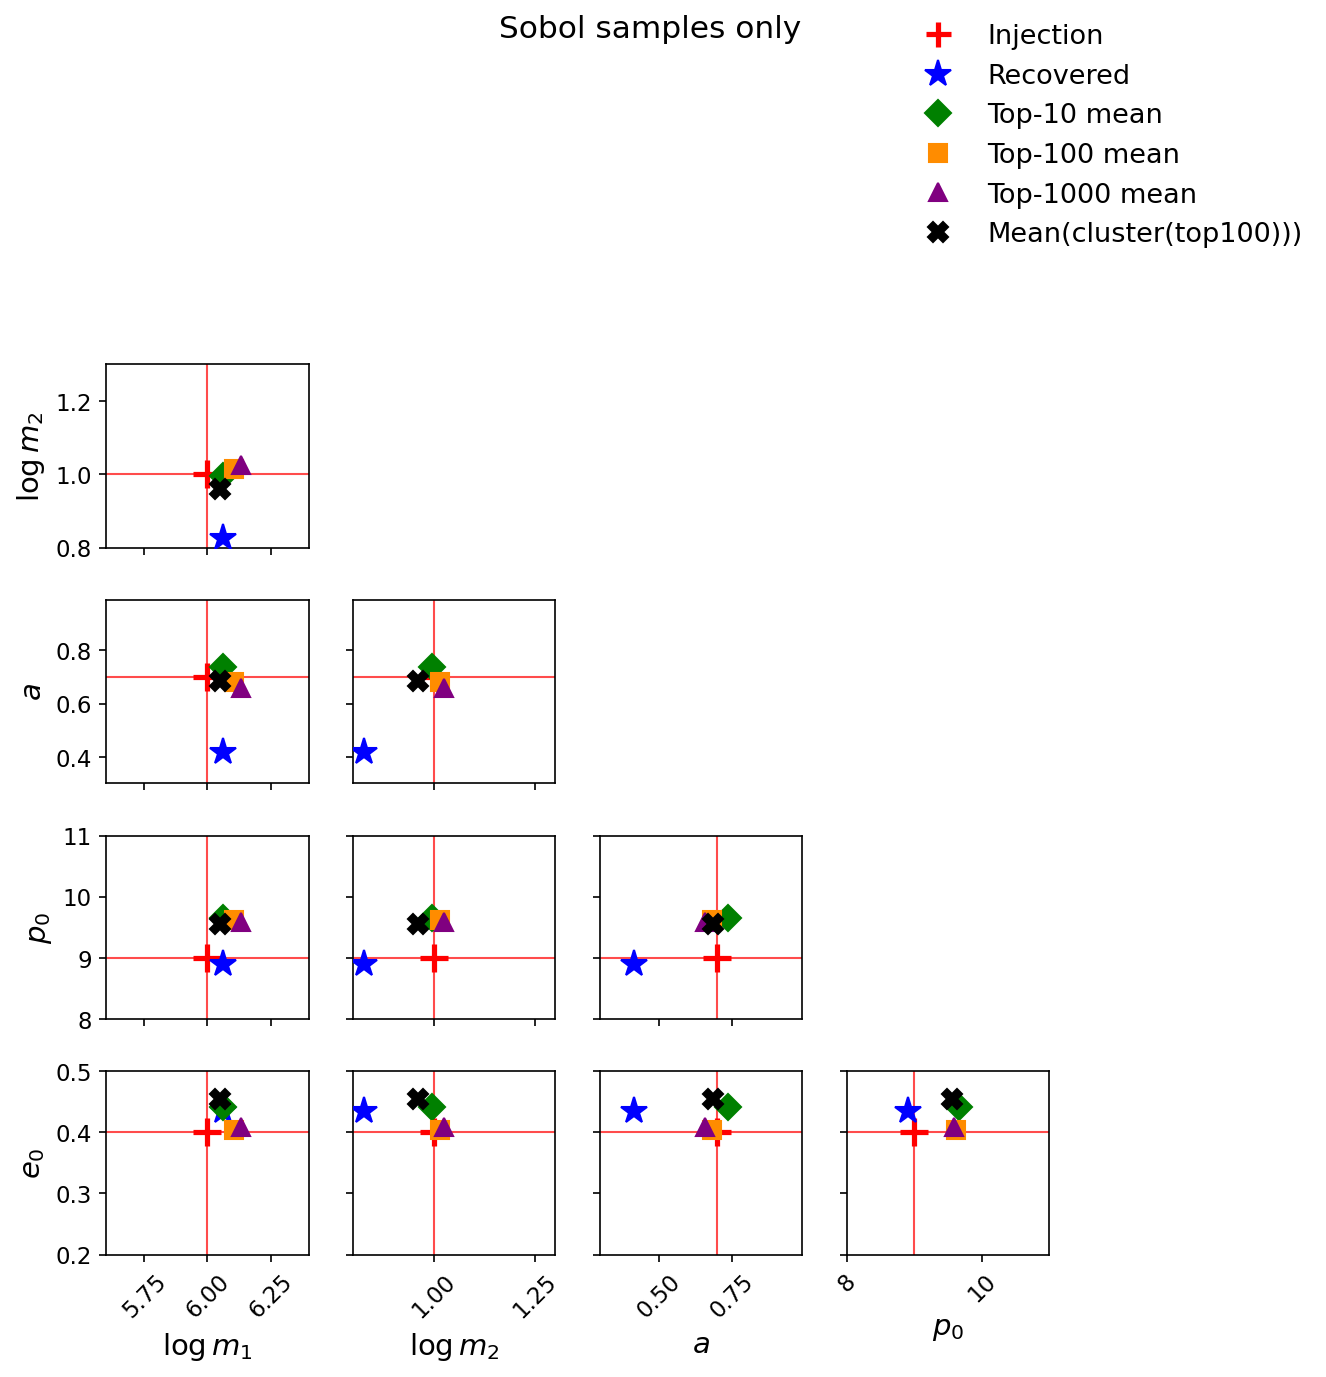

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

# injected (true) params: m1=1e6, m2=10, a=0.7, p0=9, e0=0.4
param_true = np.array([np.log10(1e6), np.log10(10), 0.7, 9.0, 0.4])

# Sobol max-log-density point (final.pkl, ckpt_1e5)
maxld_pt1 = np.array([6.059522, 0.825574, 0.416593, 8.906924, 0.434336])

# mean of the top-10 KMeans cluster-best points (one best-ld point per cluster,
# pool = top 100 by log-density; from cls_res_sobol.py)
cluster_mean_pt = np.array([6.0495, 0.9607, 0.6862, 9.5533, 0.4542])

param_ranges = [(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

# mean of the top-10 / top-100 / top-1000 Sobol samples by log-density
sorted_idx = np.argsort(logden)
topN_means = {}
topN_colors = {10: 'green', 100: 'darkorange', 1000: 'purple'}
topN_markers = {10: 'D', 100: 's', 1000: '^'}
for N in [10, 100, 1000]:
    idx = sorted_idx[-N:]
    topN_means[N] = phys_pts[idx].mean(axis=0)

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        for N, pt in topN_means.items():
            ax.plot(pt[j], pt[i], topN_markers[N], color=topN_colors[N],
                    ms=9, zorder=4)

        ax.plot(cluster_mean_pt[j], cluster_mean_pt[i], 'X', color='black',
                ms=10, zorder=4)

        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
] + [
    Line2D([0], [0], color=topN_colors[N], marker=topN_markers[N], ls='', ms=9,
           label=f'Top-{N} mean')
    for N in [10, 100, 1000]
] + [
    Line2D([0], [0], color='black', marker='X', ls='', ms=10, label='Mean(cluster(top100)))'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.suptitle('Sobol samples only', fontsize=15, y=1.02)
fig.tight_layout()
